In [24]:
import tempfile
from datetime import datetime
from multiprocessing import cpu_count
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from joblib import Parallel, delayed
from numba import njit
from hftbacktest import (
    GTC,
    LIMIT,
    BacktestAssetPoly,
    ROIVectorMarketDepthBacktest,
    Recorder,
    init_orderbook,
    polymarket_to_hbt,
)
from hftbacktest.stats import PolyAssetRecord

%matplotlib inline


In [25]:
coin = "btc"
start = datetime.fromisoformat("2026-03-15T17:00:00+00:00")
end = datetime.fromisoformat("2026-03-25T09:00:00+00:00")

market_times = pd.date_range(start=start, end=end, freq="5min", inclusive="left")
market_times[:5]

DatetimeIndex(['2026-03-15 17:00:00+00:00', '2026-03-15 17:05:00+00:00',
               '2026-03-15 17:10:00+00:00', '2026-03-15 17:15:00+00:00',
               '2026-03-15 17:20:00+00:00'],
              dtype='datetime64[us, UTC]', freq='5min')

In [ ]:
DATA_CACHE_DIR = Path(tempfile.gettempdir()) / "pm_hbt_example_cache"
L2_CACHE_DIR = DATA_CACHE_DIR / "poly_l2"
HBT_CACHE_DIR = DATA_CACHE_DIR / "poly_hbt"
L2_CACHE_DIR.mkdir(parents=True, exist_ok=True)
HBT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

BOOK_SIZE = 100


def build_5m_slug(asset_prefix: str, ts) -> str:
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    start_s = int(ts.timestamp()) // 300 * 300
    return f"{asset_prefix}-updown-5m-{start_s}"


def get_hbt_data(slug: str):
    hbt_path = HBT_CACHE_DIR / f"{slug}.npz"
    if hbt_path.exists():
        return np.load(hbt_path)["data"]

    parquet_path = L2_CACHE_DIR / f"{slug}.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
    else:
        data_type = "poly_l2"  # or "poly_snapshot"
        url = f"https://api.pmdata.dev/get-download-url/{data_type}/{slug}"
        # Get your Free API key from https://pmdata.dev/
        resp = requests.get(url, headers={"api_key": "<YOUR_API_KEY>"})
        resp.raise_for_status()
        download_url = resp.json()["download_url"]
        df = pd.read_parquet(download_url)
        if "condition_id" in df.columns:
            df = df.drop(columns=["condition_id"])
        df.to_parquet(parquet_path)

    data = polymarket_to_hbt(df)
    np.savez_compressed(hbt_path, data=data)
    return data


slugs = [build_5m_slug(coin, ts) for ts in market_times]
slugs[:5]

['btc-updown-5m-1773594000',
 'btc-updown-5m-1773594300',
 'btc-updown-5m-1773594600',
 'btc-updown-5m-1773594900',
 'btc-updown-5m-1773595200']

In [27]:
def _warm_up_one(slug: str) -> str | None:
    try:
        get_hbt_data(slug)
        return slug
    except Exception:
        return None


def warm_up_hbt_data(slugs: list[str], n_jobs: int | None = None) -> set[str]:
    rows = Parallel(n_jobs=n_jobs or cpu_count(), backend="loky")(
        delayed(_warm_up_one)(slug) for slug in slugs
    )
    return {slug for slug in rows if slug is not None}


# warm_up_hbt_data(slugs)

In [28]:
@njit
def endline_trading(
    hbt,
    recorder,
    market_start_ns: int,
    up_trigger: float,
    buy_discount: float,
    stop_long: float,
    order_qty: float,
):
    asset_no = 0
    if not init_orderbook(hbt, asset_no):
        return np.int64(0)

    tick_size = 0.01
    up_trigger = min(max(up_trigger, tick_size), 1.0 - tick_size)
    down_trigger = 1.0 - up_trigger
    buy_discount = min(max(buy_discount, -0.98), 0.98)
    stop_long = min(max(stop_long, tick_size), 1.0 - tick_size)
    stop_short = 1.0 - stop_long
    qty = np.ceil(order_qty)

    activated = False
    side = 0
    entry_submitted = False
    stop_submitted = False

    while hbt.elapse(100_000_000) == 0:
        if hbt.current_timestamp < market_start_ns:
            continue

        hbt.clear_inactive_orders(asset_no)
        depth = hbt.depth(asset_no)
        bid = depth.best_bid
        ask = depth.best_ask
        mid = (bid + ask) / 2.0

        if not activated:
            if mid >= up_trigger:
                activated = True
                side = 1
            elif mid <= down_trigger:
                activated = True
                side = -1

        if activated and (not entry_submitted):
            if side > 0:
                entry_price = up_trigger - buy_discount
                entry_price = max(tick_size, min(1.0 - tick_size, entry_price))
                entry_order_id = int(round(entry_price / tick_size))
                hbt.submit_buy_order(
                    asset_no,
                    entry_order_id,
                    entry_price,
                    qty,
                    GTC,
                    LIMIT,
                    False,
                )
            else:
                entry_price = down_trigger + buy_discount
                entry_price = max(tick_size, min(1.0 - tick_size, entry_price))
                entry_order_id = int(round(entry_price / tick_size))
                hbt.submit_sell_order(
                    asset_no,
                    entry_order_id,
                    entry_price,
                    qty,
                    GTC,
                    LIMIT,
                    False,
                )
            entry_submitted = True

        position = hbt.position(asset_no)
        if (not stop_submitted) and position > 0.0 and mid <= stop_long:
            stop_price = stop_long
            stop_order_id = int(round(stop_price / tick_size))
            hbt.submit_sell_order(
                asset_no,
                stop_order_id,
                stop_price,
                position,
                GTC,
                LIMIT,
                False,
            )
            stop_submitted = True
        elif (not stop_submitted) and position < 0.0 and mid >= stop_short:
            stop_price = stop_short
            stop_order_id = int(round(stop_price / tick_size))
            hbt.submit_buy_order(
                asset_no,
                stop_order_id,
                stop_price,
                -position,
                GTC,
                LIMIT,
                False,
            )
            stop_submitted = True

        recorder.record(hbt)

    depth = hbt.depth(asset_no)
    final_mid = (depth.best_bid + depth.best_ask) / 2.0
    if side > 0:
        return np.int64(final_mid < 0.5)
    if side < 0:
        return np.int64(final_mid > 0.5)
    return np.int64(0)

In [29]:
def run_slug_backtest(
    slug: str,
    market_start_ns: int,
    params: dict,
) -> tuple[float, int]:
    data = get_hbt_data(slug)
    enter_price = params["up_trigger"]
    taker_fee = 0.07 * enter_price * (1 - enter_price)
    marker_fee = -taker_fee * 0.2
    asset = (
        BacktestAssetPoly().data(data).trading_value_fee_model(marker_fee, taker_fee)
    )
    hbt = ROIVectorMarketDepthBacktest([asset])
    recorder = Recorder(hbt.num_assets, 5_000_000)

    reversal_flag = endline_trading(
        hbt,
        recorder.recorder,
        market_start_ns=market_start_ns,
        up_trigger=float(params["up_trigger"]),
        buy_discount=float(params["buy_discount"]),
        stop_long=float(params["stop_long"]),
        order_qty=float(params["order_qty"]),
    )
    _ = hbt.close()

    stats = PolyAssetRecord(recorder.get(0)).stats(book_size=BOOK_SIZE)
    return float(stats.earn), int(reversal_flag)


def _run_one_market(ts, params: dict):
    slug = build_5m_slug(coin, ts)

    try:
        earn, reversal_flag = run_slug_backtest(
            slug=slug,
            market_start_ns=int(pd.Timestamp(ts).value),
            params=params,
        )
        return {
            "time": ts,
            "slug": slug,
            "earn": earn,
            "reversal_flag": bool(reversal_flag),
            "skipped": False,
        }
    except Exception:
        return {
            "time": ts,
            "slug": slug,
            "earn": np.nan,
            "reversal_flag": False,
            "skipped": True,
        }


def backtest_markets(
    market_times,
    params: dict,
    n_jobs: int | None = None,
) -> pd.DataFrame:
    rows = Parallel(n_jobs=n_jobs or cpu_count(), backend="loky")(
        delayed(_run_one_market)(ts, params) for ts in market_times
    )
    return pd.DataFrame(rows).set_index("time")

In [30]:
params = {
    "up_trigger": 0.88,
    "buy_discount": 0.0,
    "stop_long": 0.35,
    "order_qty": 5.0,
}


df_bt = backtest_markets(market_times, params)
df_bt.head()

,slug,earn,reversal_flag,skipped
time,,,,
2026-03-15 17:00:00+00:00,btc-updown-5m-1773594000,0.606505,False,False
2026-03-15 17:05:00+00:00,btc-updown-5m-1773594300,0.606505,False,False
2026-03-15 17:10:00+00:00,btc-updown-5m-1773594600,0.600887,False,False
2026-03-15 17:15:00+00:00,btc-updown-5m-1773594900,0.606505,False,False
2026-03-15 17:20:00+00:00,btc-updown-5m-1773595200,0.606505,False,False


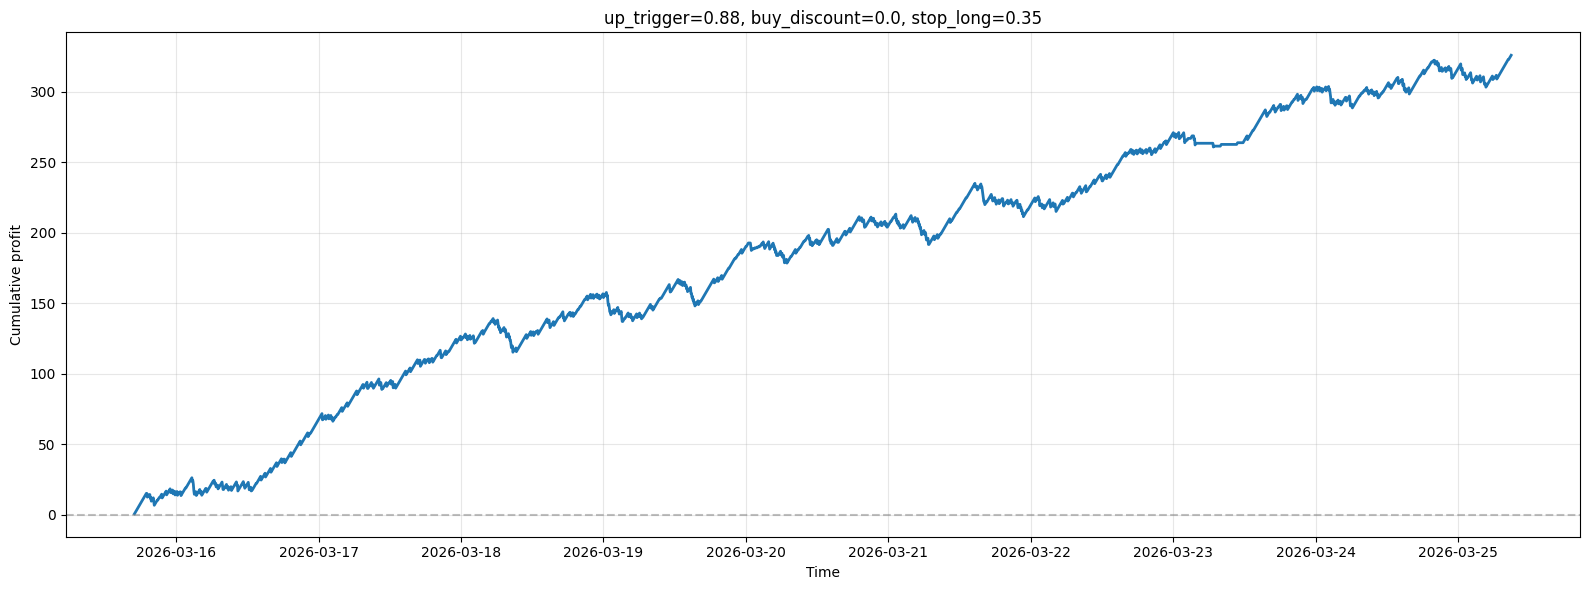

In [31]:
df_bt["cum_earn"] = df_bt["earn"].fillna(0.0).cumsum()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_bt.index, df_bt["cum_earn"], linewidth=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Cumulative profit")
ax.set_xlabel("Time")
ax.set_title(
    "up_trigger={up_trigger}, buy_discount={buy_discount}, stop_long={stop_long}".format(
        **params
    )
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()